# Example 10: Surface Rover Navigation with IMU, LCRNS, and DEM Aiding

This tutorial simulates a lunar south-pole rover using a strapdown inertial navigation system aided by LunaNet/LCRNS pseudoranges and a digital elevation model. It introduces LuPNT's surface-navigation application and the error-state EKF structure used for rover localization.

The filter state contains position, velocity, attitude error, accelerometer bias, gyroscope bias, and receiver clock terms. The IMU propagates the state at high rate; pseudorange and terrain-height updates correct the drift:

$$
\rho_i = \|\mathbf r_{rover}-\mathbf r_{sat,i}\| + c b + \epsilon_i, \qquad
h_{DEM}(E,N)-U = 0 + \epsilon_h.
$$

The tutorial emphasizes observability: gravity helps roll/pitch, curved motion helps bias estimation, LCRNS ranges constrain horizontal position and clock, and the DEM pins the vertical channel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

import os, sys
from pathlib import Path

# Use THIS repo's pylupnt/data, not a stale copy on a global PYTHONPATH (~/.zshrc) or kernelspec.
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data/ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        break
import pylupnt as pnt

np.random.seed(0)

[00.02][PyLuPNT] Initializing


## 1. Load the digital elevation model

`pnt.load_lola_dem(lat, lon)` picks the nearest PGDA product-78 site, downloads/caches its
GeoTIFF, and returns a cropped, downsampled `LunarDem` (elevations in metres relative to the
1737.4 km reference sphere). We use **Site01 — Connecting Ridge** (~89.45°S).

In [2]:
SITE_LAT, SITE_LON = -89.45, 222.8  # deg; Site01 Connecting Ridge
HALF_WIDTH_M = 4000.0

dem = pnt.load_lola_dem(SITE_LAT, SITE_LON, half_width_m=HALF_WIDTH_M, max_res=20.0)
print(f"Site      : {dem.site.id}  ({dem.site.name})")
print(f"Grid      : {dem.rows} x {dem.cols} pixels")
print(
    f"Elevation : {dem.elevation.min():.1f} .. {dem.elevation.max():.1f} m (rel. 1737.4 km)"
)

Site      : Site01  (Connecting ridge)
Grid      : 400 x 400 pixels
Elevation : 903.3 .. 1959.1 m (rel. 1737.4 km)


/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_73905/576894283.py:20: UserWarning: Glyph 8212 (\N{EM DASH}) missing from font(s) cmr10.
  plt.tight_layout()
/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8212 (\N{EM DASH}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


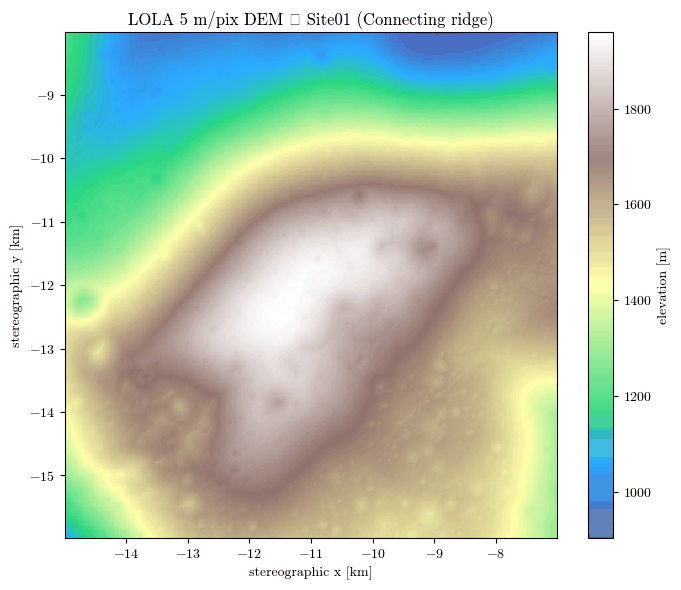

In [3]:
X = dem.x / 1e3
Y = dem.y / 1e3
Z = dem.elevation
ls = LightSource(azdeg=315, altdeg=35)
rgb = ls.shade(Z, cmap=plt.cm.terrain, blend_mode="soft", vert_exag=3.0)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(X, Y, Z, cmap="terrain", shading="auto", alpha=0.75)
ax.imshow(
    rgb,
    extent=[X.min(), X.max(), Y.min(), Y.max()],
    origin="upper",
    alpha=0.35,
    aspect="auto",
)
ax.set_xlabel("stereographic x [km]")
ax.set_ylabel("stereographic y [km]")
ax.set_title(f"LOLA 5 m/pix DEM — {dem.site.id} ({dem.site.name})")
fig.colorbar(im, ax=ax, label="elevation [m]")
plt.tight_layout()
plt.show()

## 2. LCRNS relay constellation

Five ELFO satellites from the NASA LCRNS Reference Constellation 3.1 (Cartesian states in the
Moon-centered ICRF at 2027-03-01 00:00 UTC).

In [4]:
t0_str = "2027-03-01T00:00:00"  # UTC, LCRNS Reference Constellation 3.1 epoch

lcrns_states_km = {
    "SV-1": ([-198.931445, 386.023132, 3458.355412], [-1.539867, 0.022243, -0.091059]),
    "SV-2": (
        [1089.980598, -2260.918271, -18984.562823],
        [0.280301, -0.004049, 0.016575],
    ),
    "SV-3": ([9187.665852, -260.470721, -8543.222759], [0.273629, 0.417588, -0.313828]),
    "SV-4": (
        [6484.019002, 14329.883921, -7966.345594],
        [-0.258433, 0.033951, 0.235264],
    ),
    "SV-5": (
        [-5074.242314, 14473.022751, -8638.530033],
        [-0.229931, -0.026926, -0.264381],
    ),
}

satellites = []
for name, (r_km, v_kmps) in lcrns_states_km.items():
    sc = pnt.LcrnsSatConfig()
    sc.name = name
    sc.r0_m = np.array(r_km) * 1e3
    sc.v0_mps = np.array(v_kmps) * 1e3
    satellites.append(sc)
print(f"{len(satellites)} LCRNS satellites configured")

5 LCRNS satellites configured


## 3. Configure and run the strapdown-INS simulation

The IMU accelerometer and gyroscope are simulated with the Kalibr noise model (white-noise
density + bias random walk); representative tactical-grade (LN200S-class) values are the
defaults. The rover drives a curved traverse (arcs sweep its heading), which — together with
the accelerometer sensing gravity — makes the attitude and IMU biases observable so the
filter can estimate them.

In [5]:
cfg = pnt.SurfaceNavConfig()
cfg.seed = 42
cfg.start_epoch_utc = t0_str
cfg.duration_s = 1200.0
cfg.dt_s = 1.0

cfg.site_lat_deg = SITE_LAT
cfg.site_lon_deg = SITE_LON
cfg.dem_half_width_m = HALF_WIDTH_M

# IMU (Kalibr noise model) — representative tactical-grade (LN200S-class)
cfg.accel_noise_density = 3.4e-4  # [m/s^2 / sqrt(Hz)]
cfg.accel_bias_rw = 1.0e-4  # [m/s^3 / sqrt(Hz)]
cfg.gyro_noise_density = 3.4e-6  # [rad/s / sqrt(Hz)]
cfg.gyro_bias_rw = 1.0e-6  # [rad/s^2 / sqrt(Hz)]
cfg.accel_bias0 = 1.0e-2  # truth initial accel bias 1σ/axis [m/s^2]
cfg.gyro_bias0 = 5.0e-4  # truth initial gyro bias 1σ/axis [rad/s]

# LCRNS: 1 m pseudorange noise, 3 m SISE (1-sigma)
cfg.satellites = satellites
cfg.pseudorange_sigma_m = 1.0
cfg.sise_m = 3.0
cfg.enable_dem_constraint = True

res = pnt.run_surface_nav(cfg)
N = len(res.time_s)
t = np.array(res.time_s)
print(f"Ran {N} epochs at site {res.site_id}")
print(f"Mean visible satellites : {res.n_visible.mean():.2f}")
print(f"Final 3D position error : {res.pos_err_norm[-1]:.2f} m")

Ran 1201 epochs at site Site01
Mean visible satellites : 4.00
Final 3D position error : 5.13 m


## 4. Results

### 4.1 Rover ground track over the terrain

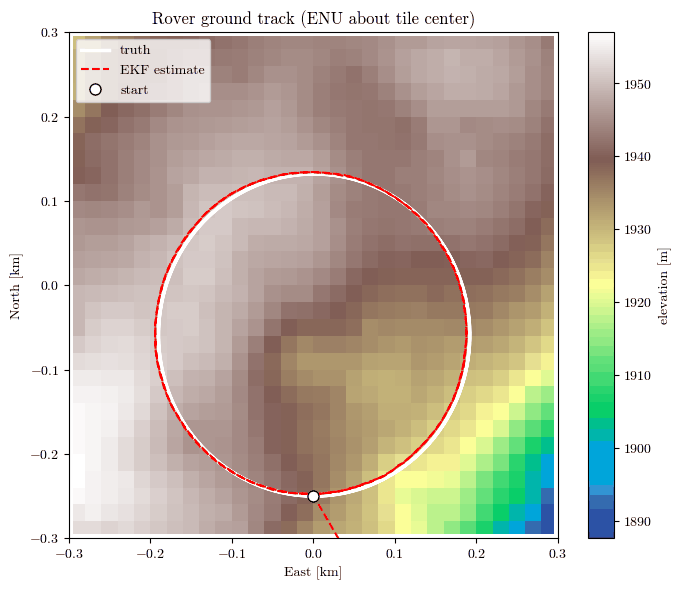

In [6]:
Xc = (dem.x - res.dem_center_x) / 1e3
Yc = (dem.y - res.dem_center_y) / 1e3

# only plot the rover within 0.5 km of the DEM center
Xc_plot = np.clip(Xc, -0.3, 0.3)
Yc_plot = np.clip(Yc, -0.3, 0.3)
# clip dem to the same region, but keep NaN for out-of-bounds pixels
dem_plot_elevation = np.full_like(dem.elevation, np.nan)
dem_plot_elevation = np.where(
    (Xc >= -0.3) & (Xc <= 0.3) & (Yc >= -0.3) & (Yc <= 0.3), dem.elevation, np.nan
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(Xc_plot, Yc_plot, dem_plot_elevation, cmap="terrain", shading="auto")
tt = np.array(res.rover_track_enu_truth) / 1e3
te = np.array(res.rover_track_enu_est) / 1e3
ax.plot(tt[:, 0], tt[:, 1], "w-", lw=2.5, label="truth")
ax.plot(te[:, 0], te[:, 1], "r--", lw=1.5, label="EKF estimate")
ax.plot(tt[0, 0], tt[0, 1], "wo", ms=8, mec="k", label="start")
ax.set_xlim(-0.3, 0.3)
ax.set_ylim(-0.3, 0.3)
ax.set_xlabel("East [km]")
ax.set_ylabel("North [km]")
ax.set_title("Rover ground track (ENU about tile center)")
ax.legend(loc="upper left")
fig.colorbar(im, ax=ax, label="elevation [m]")
plt.tight_layout()
plt.show()

### 4.2 Position error vs. filter 3σ (East / North / Up)

The DEM constraint pins the vertical channel; the residual horizontal floor is set mostly by
the 3 m per-satellite SISE.

/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_73905/1182298161.py:15: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  plt.tight_layout()
/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


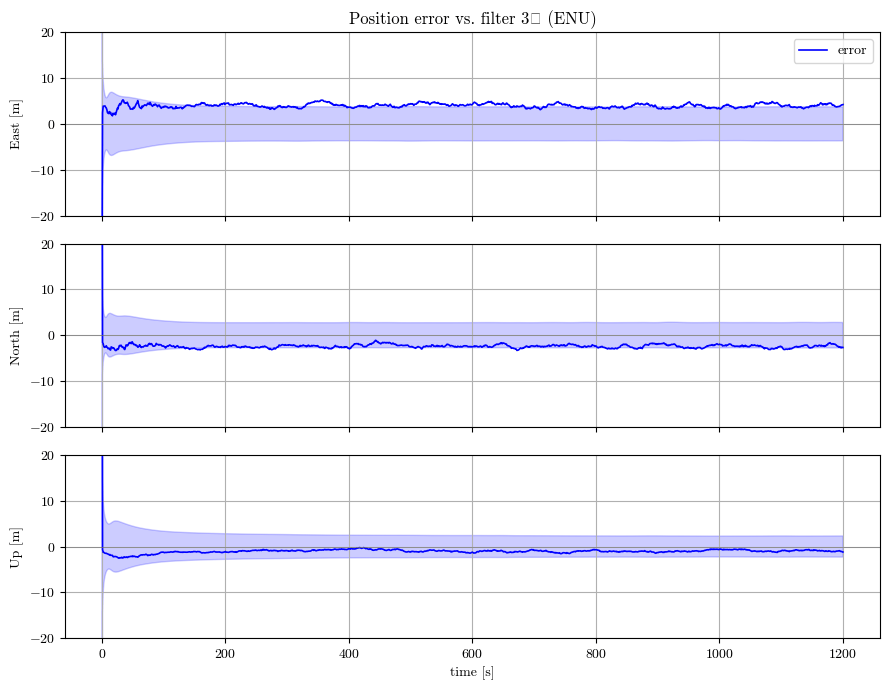

In [7]:
err = np.array(res.pos_err_enu)
sig = np.array(res.pos_sigma_enu)
labels = ["East", "North", "Up"]
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, err[:, i], "b-", lw=1.2, label="error")
    ax.fill_between(t, -3 * sig[:, i], 3 * sig[:, i], color="blue", alpha=0.2)
    ax.set_ylim(-20, 20)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_ylabel(f"{labels[i]} [m]")
    ax.grid(True)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("time [s]")
axes[0].set_title("Position error vs. filter 3σ (ENU)")
plt.tight_layout()
plt.show()

### 4.3 IMU bias estimation

The accelerometer and gyroscope biases start unknown (estimate = 0) and are estimated online.
Roll/pitch tilt is strongly observable through the accelerometer sensing gravity, and the
rover's curved motion makes the horizontal-accel and gyro biases observable; the vertical
accel bias is tied down by the DEM. Errors (truth − estimate) are shown against the filter 3σ.

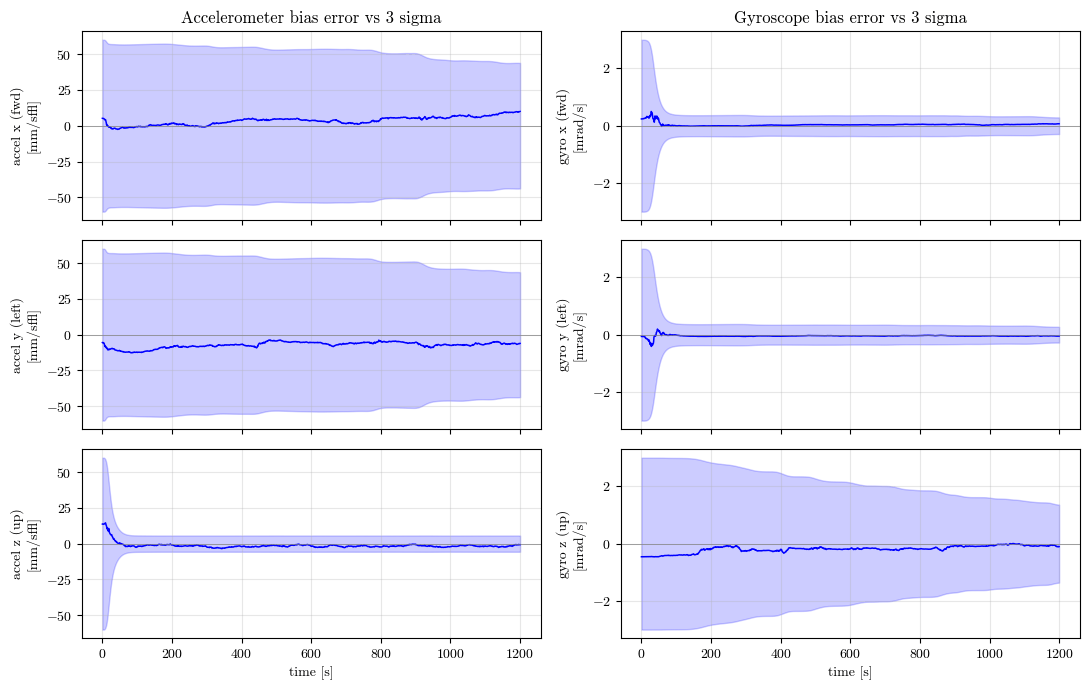

accel bias |err|: 15.43 -> 10.63 mm/s²  (31% reduced)
gyro  bias |err|: 0.542 -> 0.105 mrad/s (81% reduced)


In [8]:
ba_err = np.array(res.accel_bias_err) * 1e3  # mm/s^2
ba_sig = np.array(res.accel_bias_sigma) * 1e3
bg_err = np.array(res.gyro_bias_err) * 1e3  # mrad/s
bg_sig = np.array(res.gyro_bias_sigma) * 1e3
axlab = ["x (fwd)", "y (left)", "z (up)"]

fig, axes = plt.subplots(3, 2, figsize=(11, 7), sharex=True)
for i in range(3):
    a = axes[i, 0]
    a.plot(t, ba_err[:, i], "b-", lw=1.1)
    a.fill_between(t, -3 * ba_sig[:, i], 3 * ba_sig[:, i], color="blue", alpha=0.2)
    a.axhline(0, color="gray", lw=0.5)
    a.set_ylabel(f"accel {axlab[i]}\n[mm/s²]")
    a.grid(alpha=0.3)
    g = axes[i, 1]
    g.plot(t, bg_err[:, i], "b-", lw=1.1)
    g.fill_between(t, -3 * bg_sig[:, i], 3 * bg_sig[:, i], color="blue", alpha=0.2)
    g.axhline(0, color="gray", lw=0.5)
    g.set_ylabel(f"gyro {axlab[i]}\n[mrad/s]")
    g.grid(alpha=0.3)
axes[0, 0].set_title("Accelerometer bias error vs 3 sigma")
axes[0, 1].set_title("Gyroscope bias error vs 3 sigma")
axes[-1, 0].set_xlabel("time [s]")
axes[-1, 1].set_xlabel("time [s]")
plt.tight_layout()
plt.show()

ba0 = np.linalg.norm(ba_err[:20], axis=1).mean()
baN = np.linalg.norm(ba_err[-100:], axis=1).mean()
bg0 = np.linalg.norm(bg_err[:20], axis=1).mean()
bgN = np.linalg.norm(bg_err[-100:], axis=1).mean()
print(
    f"accel bias |err|: {ba0:.2f} -> {baN:.2f} mm/s²  ({100*(1-baN/ba0):.0f}% reduced)"
)
print(
    f"gyro  bias |err|: {bg0:.3f} -> {bgN:.3f} mrad/s ({100*(1-bgN/bg0):.0f}% reduced)"
)

### 4.4 Attitude estimation

Attitude error (rotation vector) vs the filter 3σ. Roll/pitch are tightly observed via the
gravity direction; yaw is the weakest-observed channel for a slow surface rover with
position-only aiding — the filter reports a correspondingly larger yaw uncertainty.

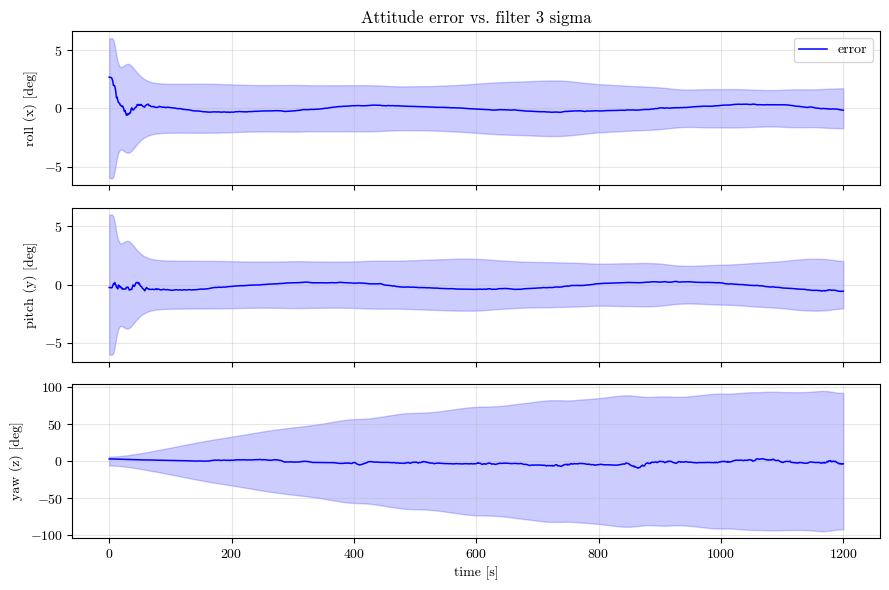

In [9]:
ae = np.array(res.att_err_deg)
asig = np.array(res.att_sigma_deg)
rp = ["roll (x)", "pitch (y)", "yaw (z)"]
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, ae[:, i], "b-", lw=1.1, label="error")
    ax.fill_between(t, -3 * asig[:, i], 3 * asig[:, i], color="blue", alpha=0.2)
    ax.set_ylabel(f"{rp[i]} [deg]")
    ax.grid(alpha=0.3)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("time [s]")
axes[0].set_title("Attitude error vs. filter 3 sigma")
plt.tight_layout()
plt.show()

### 4.5 Does the DEM constraint help?

Re-run with the DEM constraint disabled and compare the steady-state error. Without the
terrain tie the vertical channel is far weaker (the near-overhead LCRNS geometry constrains
height poorly).

DEM constraint ON     vertical=  0.91 m   horizontal=  4.64 m
DEM constraint OFF    vertical= 29.40 m   horizontal=  5.01 m


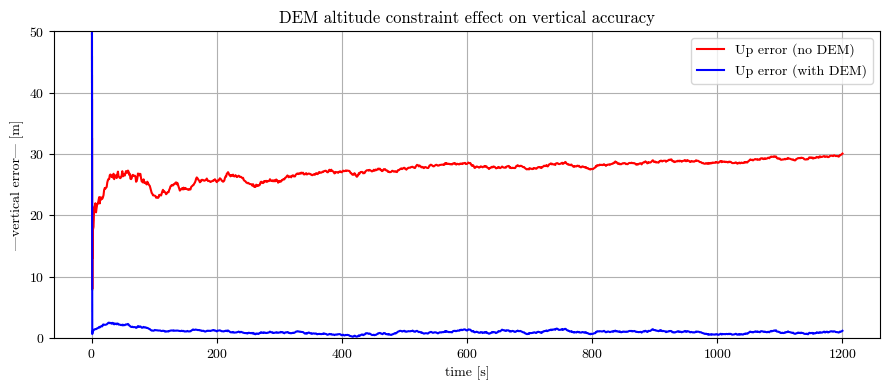

In [10]:
def run(dem_on):
    c = pnt.SurfaceNavConfig()
    for attr in (
        "seed",
        "start_epoch_utc",
        "duration_s",
        "dt_s",
        "site_lat_deg",
        "site_lon_deg",
        "dem_half_width_m",
        "accel_noise_density",
        "accel_bias_rw",
        "gyro_noise_density",
        "gyro_bias_rw",
        "accel_bias0",
        "gyro_bias0",
        "pseudorange_sigma_m",
        "sise_m",
    ):
        setattr(c, attr, getattr(cfg, attr))
    c.satellites = satellites
    c.enable_dem_constraint = dem_on
    return pnt.run_surface_nav(c)


res_on, res_off = run(True), run(False)
for name, r in (("DEM constraint ON", res_on), ("DEM constraint OFF", res_off)):
    e = np.array(r.pos_err_enu)[-100:]
    v = np.mean(np.abs(e[:, 2]))
    h = np.mean(np.linalg.norm(e[:, :2], axis=1))
    print(f"{name:20s}  vertical={v:6.2f} m   horizontal={h:6.2f} m")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    res_off.time_s,
    np.abs(np.array(res_off.pos_err_enu)[:, 2]),
    "r-",
    label="Up error (no DEM)",
)
ax.plot(
    res_on.time_s,
    np.abs(np.array(res_on.pos_err_enu)[:, 2]),
    "b-",
    label="Up error (with DEM)",
)
ax.set_xlabel("time [s]")
ax.set_ylabel("|vertical error| [m]")
ax.set_title("DEM altitude constraint effect on vertical accuracy")
ax.legend()
ax.set_ylim(0, 50)
ax.grid(True)
plt.tight_layout()
plt.show()

### 4.6 Visible satellites and clock estimation

/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_73905/3343129434.py:15: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  plt.tight_layout()


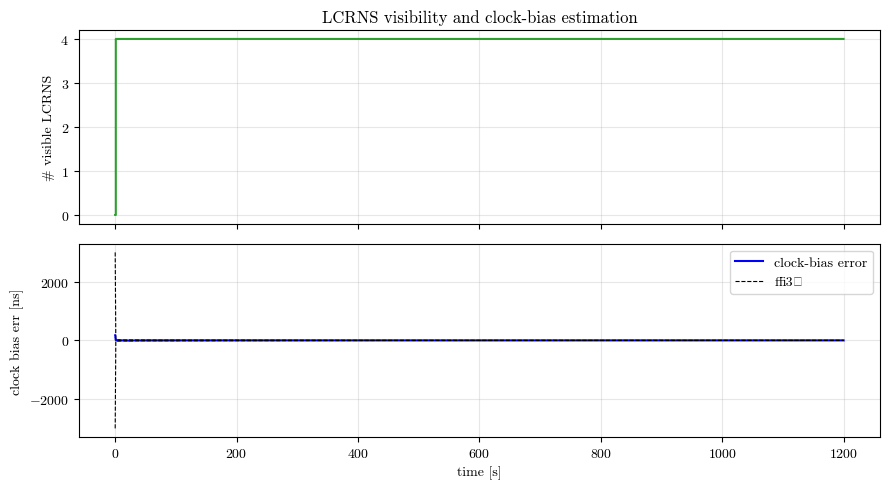

In [11]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
a1.step(res.time_s, res.n_visible, where="post", color="tab:green")
a1.set_ylabel("# visible LCRNS")
a1.grid(alpha=0.3)
a1.set_title("LCRNS visibility and clock-bias estimation")
cb_err = np.array(res.clock_bias_err) * 1e9
cb_sig = np.array(res.clock_bias_sigma) * 1e9
a2.plot(res.time_s, cb_err, "b-", label="clock-bias error")
a2.plot(res.time_s, 3 * cb_sig, "k--", lw=0.8, label="±3σ")
a2.plot(res.time_s, -3 * cb_sig, "k--", lw=0.8)
a2.set_xlabel("time [s]")
a2.set_ylabel("clock bias err [ns]")
a2.legend()
a2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

This notebook used LuPNT's surface-navigation stack to connect inertial mechanization, range measurements, terrain constraints, and EKF covariance diagnostics.

- The IMU is simulated with white noise and bias random walk, then fused in an error-state EKF.
- LCRNS pseudoranges provide absolute position and receiver-clock information.
- The DEM altitude constraint strongly improves the vertical channel.
- Bias and attitude plots show whether the filter covariance is consistent with the true estimation error.

The same pattern can be extended to wheel odometry, visual odometry, hazard-camera landmarks, or a higher-fidelity rover dynamics model.